# Capstone Project: Predictive Spatial Spectrum Management in Broadband Wireless Networks
## Module 24 – Capstone Project – Final Report
**UC Berkeley Professional Certificate in Machine Learning and Artificial Intelligence**

## 1. Introduction & Business Problem

Mobile networks in dense urban areas must continuously adjust antenna beams to follow moving users. When the network reacts too late, signal quality drops and interference increases.  

This project builds a machine learning pipeline that predicts future signal conditions, recommends the best antenna beam in advance, and identifies users at high risk of interference — enabling the network to act proactively.

## 2. Data Sources

Two data sources were used:

- **Synthetic Data**: Generated to simulate realistic user mobility, signal metrics (RSRP, RSRQ, SINR), Doppler shift, beam indices, and multi-cell interference.
- **Real-World Data**: Public O-RAN mobility dataset containing real base-station measurements of RSRP, RSRQ, and SINR for external validation.

In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV, cross_val_score
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, f1_score, ConfusionMatrixDisplay,
                             mean_absolute_error, make_scorer, mean_squared_error, r2_score, precision_score, recall_score, precision_recall_curve, average_precision_score)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

In [181]:
# The following is generating synthetic data

np.random.seed(42)
n_ues = 20
n_timesteps = 500
dt = 0.2
records = []

base_stations = [
    {"id": 0, "x": 0,   "y": 0},
    {"id": 1, "x": 450, "y": 100},
    {"id": 2, "x": 200, "y": 420}
]

for ue_id in range(n_ues):
    x = np.random.uniform(50, 750)
    y = np.random.uniform(50, 750)
    speed = np.random.uniform(1.0, 10.0)
    heading = np.random.uniform(0, 2 * np.pi)
    pause = 0.0
    target_x, target_y = x, y
    vx = vy = 0.0

    for t in range(n_timesteps):
        if pause > 0:
            pause -= dt
            vx = vy = 0.0
        else:
            dist_to_target = np.sqrt((x - target_x)**2 + (y - target_y)**2)
            if dist_to_target < 5:
                pause = np.random.uniform(1, 6)
                target_x = np.random.uniform(30, 770)
                target_y = np.random.uniform(30, 770)
                heading = np.arctan2(target_y - y, target_x - x)
            else:
                heading = np.arctan2(target_y - y, target_x - x) + np.random.normal(0, 0.05)
                vx = speed * np.cos(heading)
                vy = speed * np.sin(heading)
                x += vx * dt
                y += vy * dt

        x = np.clip(x, 10, 790)
        y = np.clip(y, 10, 790)

        # Multi-cell measurements
        rsrps = []
        for bs in base_stations:
            dist = np.sqrt((x - bs["x"])**2 + (y - bs["y"])**2) + 1e-3
            rsrp = -(28 + 22 * np.log10(dist)) + np.random.normal(0, 3.5)
            rsrps.append(rsrp)
        rsrps = np.array(rsrps)
        serving_idx = np.argmax(rsrps)
        serving_rsrp = rsrps[serving_idx]
        serving_bs = base_stations[serving_idx]

        interference = np.sum(10**(rsrps / 10)) - 10**(serving_rsrp / 10)
        sinr = 10 * np.log10(10**(serving_rsrp / 10) / (interference + 1e-12))
        rsrq = serving_rsrp - 10 * np.log10(12) + np.random.normal(-1, 1.5)

        # Doppler
        dist_to_serving = np.sqrt((x - serving_bs["x"])**2 + (y - serving_bs["y"])**2) + 1e-3
        radial_velocity = (vx * (x - serving_bs["x"]) + vy * (y - serving_bs["y"])) / dist_to_serving
        doppler_hz = (radial_velocity / 3e8) * 3.5e9

        # Beam Index (location + orientation)
        aoa = np.arctan2(y - serving_bs["y"], x - serving_bs["x"])
        relative_angle = (aoa - heading + np.pi) % (2 * np.pi) - np.pi
        beam_score = aoa + 0.35 * relative_angle
        ssb_beam_idx = int(((beam_score + np.pi) / (2 * np.pi)) * 64) % 64

        records.append({
            "ue_id": ue_id,
            "timestep": t,
            "x": round(x, 2),
            "y": round(y, 2),
            "speed_mps": round(np.sqrt(vx**2 + vy**2), 2),
            "heading_rad": round(heading, 3),
            "ssb_beam_idx": ssb_beam_idx,
            "doppler_hz": round(doppler_hz, 1),
            "rsrp_dbm": round(serving_rsrp, 2),
            "rsrq_db": round(rsrq, 2),
            "sinr_db": round(sinr, 2),
            "serving_cell": serving_idx,
            "prb_util": round(np.clip(40 + (serving_rsrp + 90)*0.7 + np.random.normal(0, 10), 5, 95), 1)
        })

df = pd.DataFrame(records)
print("Raw dataset shape:", df.shape)
df.head()


Raw dataset shape: (10000, 13)


,ue_id,timestep,x,y,speed_mps,heading_rad,ssb_beam_idx,doppler_hz,rsrp_dbm,rsrq_db,sinr_db,serving_cell,prb_util
0,0,0,312.18,715.5,0.0,-1.825,55,0.0,-85.03,-97.61,-0.26,2,37.8
1,0,1,312.18,715.5,0.0,-1.825,55,0.0,-79.67,-90.24,13.70,2,32.0
2,0,2,312.18,715.5,0.0,-1.825,55,0.0,-85.46,-100.46,4.17,2,36.9
3,0,3,312.18,715.5,0.0,-1.825,40,0.0,-80.64,-92.25,0.33,1,41.4
4,0,4,312.18,715.5,0.0,-1.825,55,0.0,-81.98,-94.72,3.58,2,35.4


## Flowing are using synthetic data for baseline modeling ##

## 3. Data Loading & Cleaning

This section loads both the synthetic and real-world datasets, handles missing values, removes unrealistic measurements, and creates the target variables needed for modeling (`high_interference` and `target_beam_idx`).

In [182]:
#Data Cleaning & Feature Engineering for systhetic data
print("Missing values:\n", df.isnull().sum())

# Classification target
df["high_interference"] = ((df["sinr_db"] < 5) | (df["prb_util"] > 75)).astype(int)

# Regression target (next beam)
df["target_beam_idx"] = df.groupby("ue_id")["ssb_beam_idx"].shift(-1)

# Feature engineering
df["rsrp_delta"] = df.groupby("ue_id")["rsrp_dbm"].diff()

for lag in [1, 2]:
    df[f"rsrp_lag{lag}"] = df.groupby("ue_id")["rsrp_dbm"].shift(lag)
    df[f"sinr_lag{lag}"] = df.groupby("ue_id")["sinr_db"].shift(lag)

df = df.dropna().reset_index(drop=True)

print("\nCleaned shape:", df.shape)
print("\nTarget distribution (High Interference):")
print(df["high_interference"].value_counts(normalize=True).round(3))



Missing values:
 ue_id           0
timestep        0
x               0
y               0
speed_mps       0
heading_rad     0
ssb_beam_idx    0
doppler_hz      0
rsrp_dbm        0
rsrq_db         0
sinr_db         0
serving_cell    0
prb_util        0
dtype: int64

Cleaned shape: (9940, 20)

Target distribution (High Interference):
high_interference
1    0.57
0    0.43
Name: proportion, dtype: float64


In [183]:

# Real O-RAN Data – Loading & Cleaning

filename = "data/neigh_measurements_1.txt"

records = []
with open(filename, "r") as f:
    for line in f:
        try:
            data = json.loads(line.strip())
            meas = data.get("RrcMeasurementReportResultInfo", {})
            serving = meas.get("ServingCellInfo", {})
            
            rsrp_raw = serving.get("SsbRsrpResult")
            rsrq_raw = serving.get("SsbRsrqResult")
            sinr_raw = serving.get("SsbSinrResult")
            
            if rsrp_raw is not None and sinr_raw is not None:
                records.append({
                    "rsrp_raw": rsrp_raw,
                    "rsrq_raw": rsrq_raw,
                    "sinr_raw": sinr_raw
                })
        except:
            continue

real_df = pd.DataFrame(records)

# Convert encoded values to approximate real units
real_df["rsrp_dbm"] = real_df["rsrp_raw"] - 156
real_df["rsrq_db"]  = (real_df["rsrq_raw"] - 40) / 2
real_df["sinr_db"]  = (real_df["sinr_raw"] / 2) - 23

# Filter realistic ranges
real_df = real_df[
    (real_df["rsrp_dbm"] >= -140) & (real_df["rsrp_dbm"] <= -40) &
    (real_df["sinr_db"]  >= -20)  & (real_df["sinr_db"]  <= 40)
].copy()

# Create target
real_df["high_interference"] = ((real_df["sinr_db"] < 5) | (real_df["rsrp_dbm"] < -95)).astype(int)
real_df = real_df.dropna().reset_index(drop=True)

print("Cleaned real_df shape:", real_df.shape)
print("\nClass distribution:")
print(real_df["high_interference"].value_counts())

Cleaned real_df shape: (396322, 7)

Class distribution:
high_interference
0    395241
1      1081
Name: count, dtype: int64


**Insight:**  
The real O-RAN data is highly imbalanced, with far more Low Risk samples than High Risk samples. High Risk users generally have lower SINR, which is consistent with the pattern observed in the synthetic data. These differences highlight the sim-to-real gap.

## 4. Exploratory Data Analysis (EDA)

Exploratory analysis is performed to understand the distributions of key features, relationships between variables, and spatial patterns of signal quality.  
Visualizations include distribution plots, a correlation heatmap, and user location plots colored by SINR.

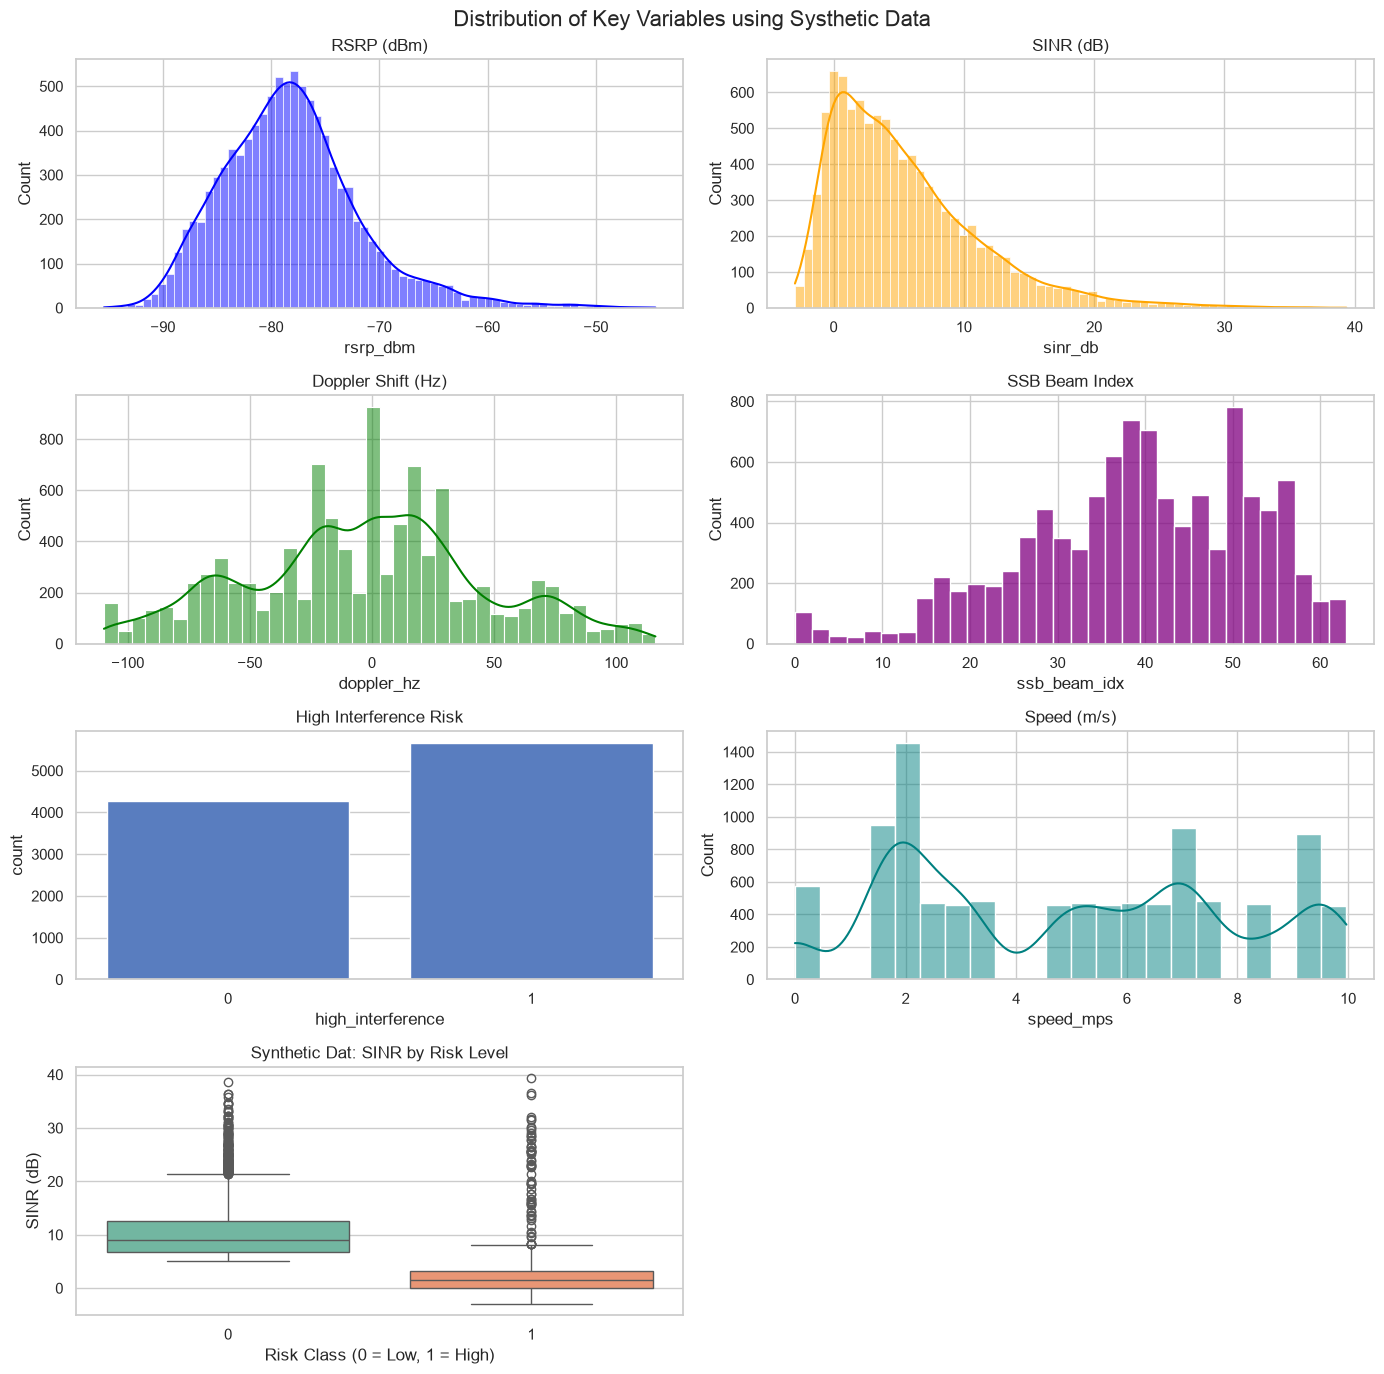

In [184]:
#EDA Visualizations for synthetic data

# Distributions
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
fig.suptitle("Distribution of Key Variables using Systhetic Data", fontsize=16)

sns.histplot(df["rsrp_dbm"], kde=True, ax=axes[0,0], color="blue")
axes[0,0].set_title("RSRP (dBm)")

sns.histplot(df["sinr_db"], kde=True, ax=axes[0,1], color="orange")
axes[0,1].set_title("SINR (dB)")

sns.histplot(df["doppler_hz"], kde=True, ax=axes[1,0], color="green")
axes[1,0].set_title("Doppler Shift (Hz)")

sns.histplot(df["ssb_beam_idx"], bins=32, ax=axes[1,1], color="purple")
axes[1,1].set_title("SSB Beam Index")

sns.countplot(x="high_interference", data=df, ax=axes[2,0])
axes[2,0].set_title("High Interference Risk")

sns.histplot(df["speed_mps"], kde=True, ax=axes[2,1], color="teal")
axes[2,1].set_title("Speed (m/s)")

sns.boxplot(x="high_interference", y="sinr_db", data=df, ax=axes[3, 0], palette="Set2")
axes[3, 0].set_title("Synthetic Dat: SINR by Risk Level")
axes[3, 0].set_xlabel("Risk Class (0 = Low, 1 = High)")
axes[3, 0].set_ylabel("SINR (dB)")

axes[3, 1].axis("off")   # Hide the empty subplot

plt.tight_layout()
plt.show()



**Insight:**  
The RSRP distribution shows RSRP values are mostly concentrated in a typical operating range, but the lower tail of the distribution represents users with weak signal strength who are more vulnerable to interference.  
The SINR distribution shows a wide range of signal conditions. A noticeable portion of users experience low SINR, which is associated with higher interference risk. 
Count Plot of High Risk vs Low Risk shows more Low Risk samples than High Risk samples. This class imbalance is important to consider when evaluating model performance, which is why F1-Score, Precision, and Recall are used in addition to Accuracy.
In the synthetic data, High Risk users (class 1) clearly have lower SINR values compared to Low Risk users (class 0). This separation supports the use of SINR as a strong feature for detecting interference risk.

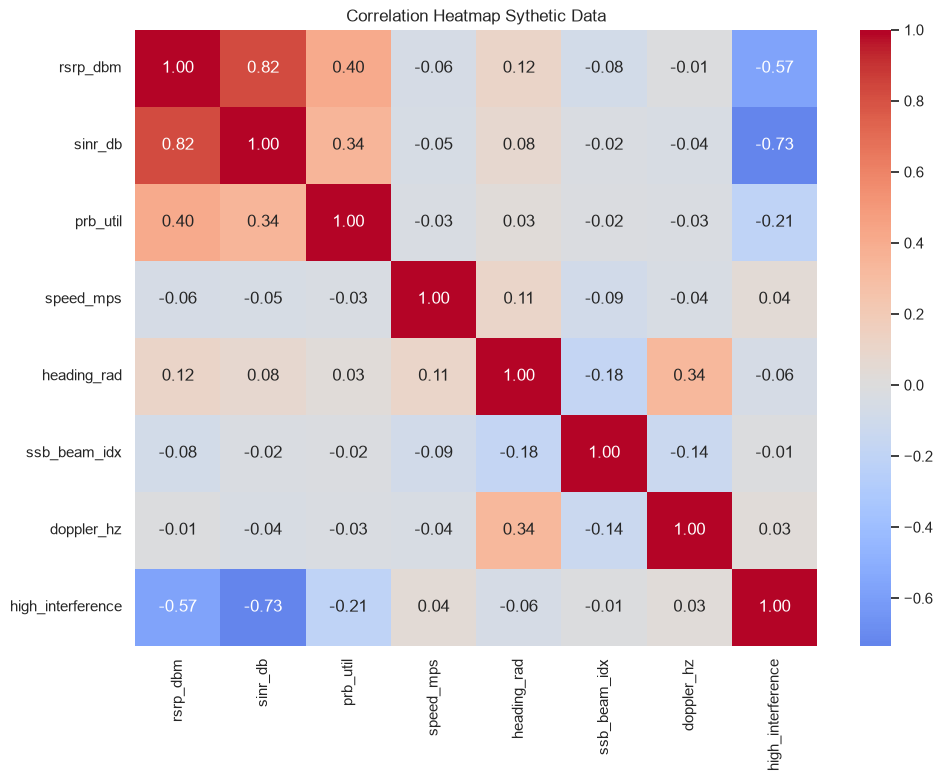

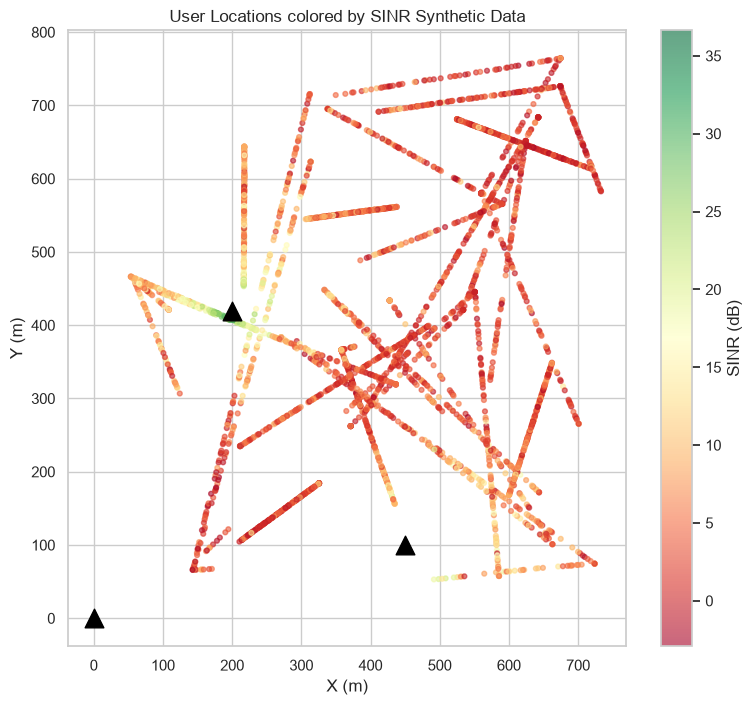

In [185]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
corr_cols = ["rsrp_dbm", "sinr_db", "prb_util", "speed_mps", "heading_rad", 
             "ssb_beam_idx", "doppler_hz", "high_interference"]
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap Sythetic Data")
plt.show()

# Spatial plot
plt.figure(figsize=(9, 8))
sample = df.sample(min(3000, len(df)))
sc = plt.scatter(sample["x"], sample["y"], c=sample["sinr_db"], cmap="RdYlGn", alpha=0.6, s=12)
plt.colorbar(sc, label="SINR (dB)")
for bs in base_stations:
    plt.scatter(bs["x"], bs["y"], c="black", s=180, marker="^")
plt.title("User Locations colored by SINR Synthetic Data")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.show()

**Insight:**
Correlation Heatmap:
SINR and RSRP show the strongest (negative) relationship with high-interference risk. This confirms that weaker signal quality is closely linked to higher interference risk. Other features such as speed and Doppler have much weaker correlations.

Spatial Plot (User Locations colored by SINR): 
Signal quality is clearly higher near base stations and drops as users move away or travel between cells. The orange and red areas indicate zones where users are more likely to experience interference.

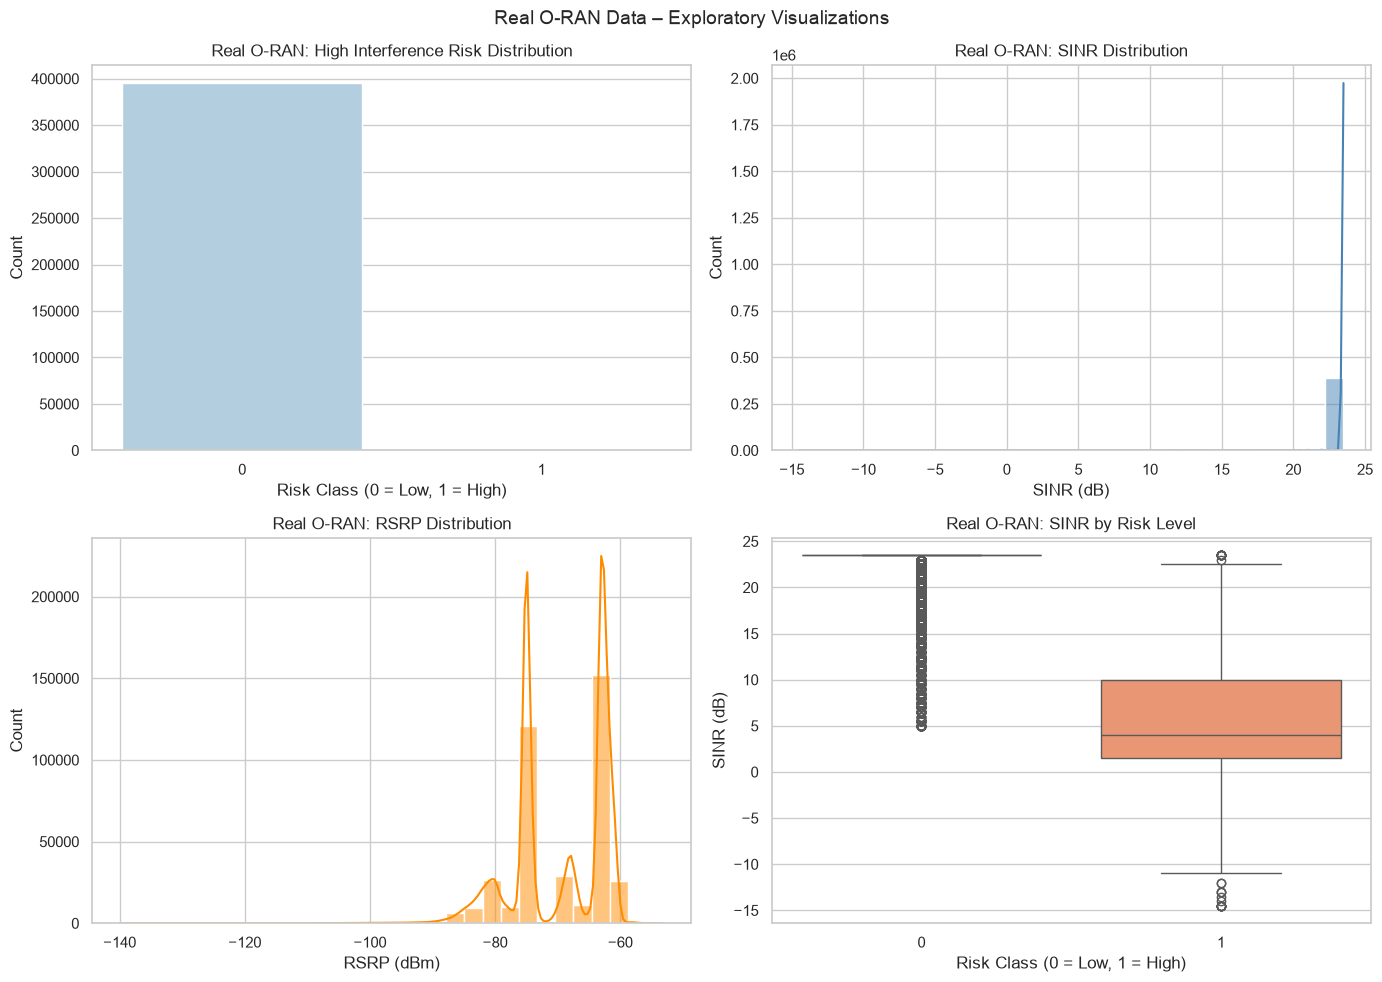

In [186]:
# ============================================================
# Real O-RAN Data – Exploratory Visualizations
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Class Distribution
sns.countplot(x="high_interference", data=real_df, ax=axes[0, 0], palette="Blues")
axes[0, 0].set_title("Real O-RAN: High Interference Risk Distribution")
axes[0, 0].set_xlabel("Risk Class (0 = Low, 1 = High)")
axes[0, 0].set_ylabel("Count")

# 2. SINR Distribution
sns.histplot(real_df["sinr_db"], bins=30, kde=True, ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Real O-RAN: SINR Distribution")
axes[0, 1].set_xlabel("SINR (dB)")

# 3. RSRP Distribution
sns.histplot(real_df["rsrp_dbm"], bins=30, kde=True, ax=axes[1, 0], color="darkorange")
axes[1, 0].set_title("Real O-RAN: RSRP Distribution")
axes[1, 0].set_xlabel("RSRP (dBm)")

# 4. SINR by Risk Level
sns.boxplot(x="high_interference", y="sinr_db", data=real_df, ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Real O-RAN: SINR by Risk Level")
axes[1, 1].set_xlabel("Risk Class (0 = Low, 1 = High)")
axes[1, 1].set_ylabel("SINR (dB)")

plt.suptitle("Real O-RAN Data – Exploratory Visualizations", fontsize=14)
plt.tight_layout()
plt.show()

**Insight:**  
The real O-RAN data is highly imbalanced, with far more Low Risk samples than High Risk samples. High Risk users generally show lower SINR values, which is consistent with the pattern seen in the synthetic data. These plots also highlight differences in signal distributions between synthetic and real measurements (sim-to-real gap).
Most samples belong to the Low Risk class, while only a small portion are High Risk. This imbalance is important when interpreting model performance. 
The SINR values in the real network cover a wide range. A portion of users experience low SINR, which increases their likelihood of being classified as high interference risk.
Most RSRP values fall within a typical operating range, but the lower end of the distribution represents users with weak signal strength who are more vulnerable to interference.
High Risk users in the real O-RAN data tend to have lower SINR compared to Low Risk users. This pattern supports the use of SINR as a key feature for interference risk detection.

**Insight:**  
The real O-RAN data is highly imbalanced, with far more Low Risk samples than High Risk samples. High Risk users generally have lower SINR, which is consistent with the pattern observed in the synthetic data. These differences highlight the sim-to-real gap.

**Addressing Class Imbalance:**  
The real O-RAN dataset is highly imbalanced. To handle this, stratified cross-validation was used, evaluation focused on F1-Score, Precision, and Recall (instead of Accuracy alone), and the decision threshold was adjusted to achieve a better balance between detecting high-risk users and limiting false alarms.

## 5. Feature Engineering

Relevant features are selected and prepared for modeling.  
Two target variables are used:

- `high_interference` → for the classification task (High Risk vs Low Risk)
- `target_beam_idx` → for the regression task (Next Beam Prediction)

Numerical features are scaled using `StandardScaler` so that models sensitive to feature magnitude (such as KNN and Logistic Regression) can perform effectively.

In [187]:
# ============================================================
# 5. Feature Engineering
# ============================================================

# ----------------------------------------------------------
# Classification Features
# ----------------------------------------------------------
clf_features = ["rsrp_dbm", "rsrq_db", "sinr_db"]

X_clf = df[clf_features]
y_clf = df["high_interference"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print("Classification features:", clf_features)
print("X_train_c_scaled shape:", X_train_c_scaled.shape)

# ----------------------------------------------------------
# Regression Features
# ----------------------------------------------------------
reg_features = [
    "rsrp_dbm", "rsrq_db", "sinr_db", "prb_util",
    "speed_mps", "heading_rad", "ssb_beam_idx", "doppler_hz", "x", "y"
]

X_reg = df[reg_features]
y_reg = df["target_beam_idx"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

print("\nRegression features:", reg_features)
print("X_train_r_scaled shape:", X_train_r_scaled.shape)

Classification features: ['rsrp_dbm', 'rsrq_db', 'sinr_db']
X_train_c_scaled shape: (7455, 3)

Regression features: ['rsrp_dbm', 'rsrq_db', 'sinr_db', 'prb_util', 'speed_mps', 'heading_rad', 'ssb_beam_idx', 'doppler_hz', 'x', 'y']
X_train_r_scaled shape: (7455, 10)


**Insight:**  
For the classification task, the most important signal quality features (RSRP, RSRQ, and SINR) were selected.  
For the regression task (next beam prediction), additional mobility and location features were included to capture user movement patterns.  
All numerical features were scaled to ensure fair treatment by distance-based and linear models.

## 6. Modeling – Classification (High Interference Risk)

This section evaluates multiple classification models to detect users at high risk of interference.

### 6.1 Baseline Models

Baseline models are trained without adjusting for class imbalance.  
The main baseline used for comparison is the Random Forest classifier.

BASELINE: Random Forest – High Interference Classification
Accuracy : 1.0000
F1-Score : 1.0000

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      1068
   High Risk       1.00      1.00      1.00      1417

    accuracy                           1.00      2485
   macro avg       1.00      1.00      1.00      2485
weighted avg       1.00      1.00      1.00      2485



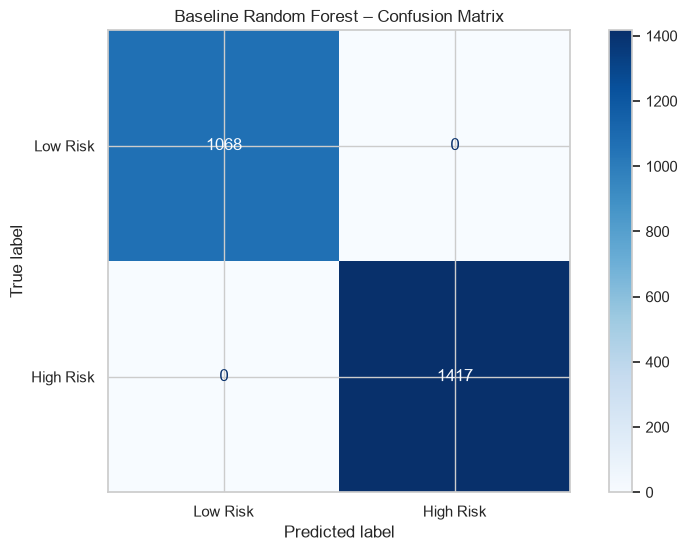

In [188]:
# ============================================================
#  Baseline Model – Random Forest Classifier
# ============================================================

print("="*60)
print("BASELINE: Random Forest – High Interference Classification")
print("="*60)

# Features and target
feature_cols = [
    "rsrp_dbm", "rsrq_db", "sinr_db", "prb_util",
    "speed_mps", "heading_rad", "ssb_beam_idx", "doppler_hz"
]

X = df[feature_cols]
y = df["high_interference"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train baseline model
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_scaled, y_train)
y_pred_baseline = rf_baseline.predict(X_test_scaled)

# Evaluation
print(f"Accuracy : {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_baseline):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=["Low Risk", "High Risk"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"])
disp.plot(cmap="Blues")
plt.title("Baseline Random Forest – Confusion Matrix")
plt.show()

**Insight:**  
The baseline Random Forest model provides a strong reference point for high-interference risk detection. It will be compared against balanced models and hyperparameter-tuned versions in the following subsections.

### 6.2 Addressing Class Imbalance

To improve the model’s ability to detect the minority class (High Risk), the main classification models are re-trained using `class_weight="balanced"`.  

This setting tells the model to pay more attention to the less frequent High Risk samples.  
Results are compared with the original baseline performance.

MODELS WITH class_weight='balanced'

Random Forest (balanced)
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      1068
   High Risk       1.00      1.00      1.00      1417

    accuracy                           1.00      2485
   macro avg       1.00      1.00      1.00      2485
weighted avg       1.00      1.00      1.00      2485


Logistic Regression (balanced)
Accuracy  : 0.9823
Precision : 0.9907
Recall    : 0.9781
F1-Score  : 0.9844
              precision    recall  f1-score   support

    Low Risk       0.97      0.99      0.98      1068
   High Risk       0.99      0.98      0.98      1417

    accuracy                           0.98      2485
   macro avg       0.98      0.98      0.98      2485
weighted avg       0.98      0.98      0.98      2485


Decision Tree (balanced)
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.000

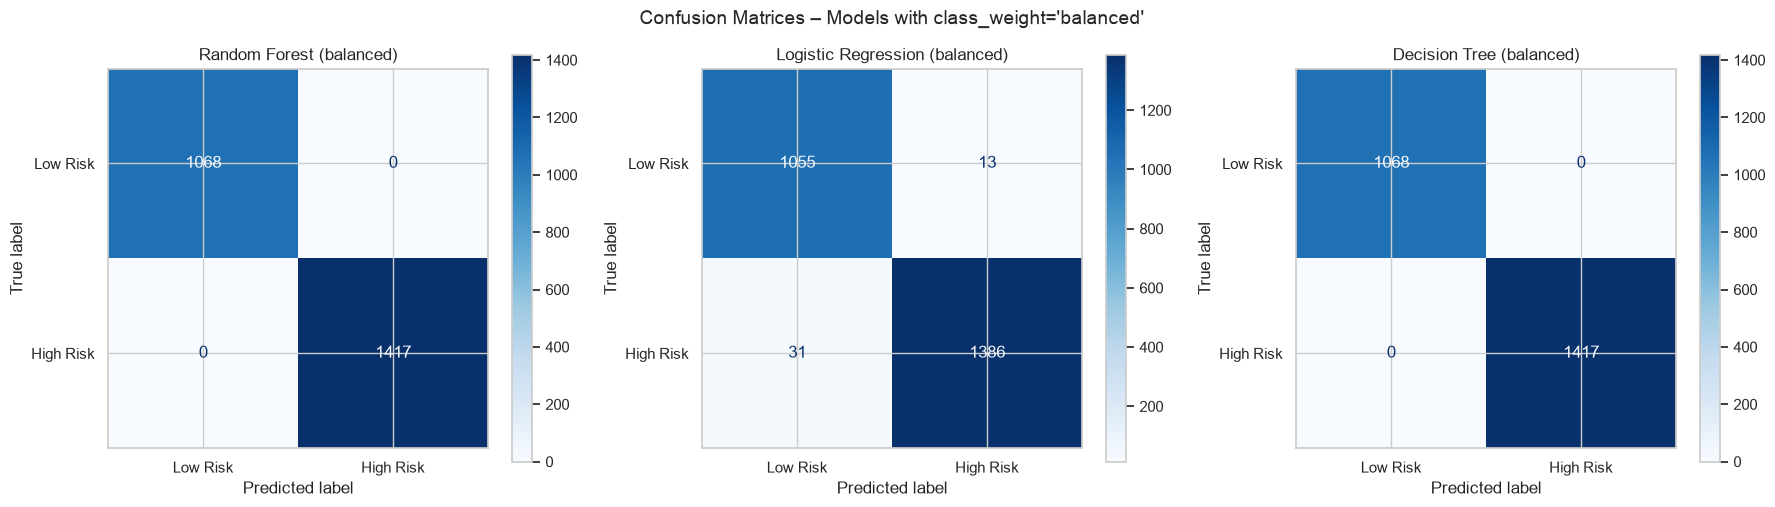


Summary of Balanced Models:
                            Model  Accuracy  Precision  Recall  F1-Score
0        Random Forest (balanced)    1.0000     1.0000  1.0000    1.0000
1  Logistic Regression (balanced)    0.9823     0.9907  0.9781    0.9844
2        Decision Tree (balanced)    1.0000     1.0000  1.0000    1.0000


In [189]:
# ============================================================
# 6.2 Models with class_weight="balanced"
# ============================================================

print("="*70)
print("MODELS WITH class_weight='balanced'")
print("="*70)

# Use the same scaled data from Section 6.1
# (X_train_scaled, X_test_scaled, y_train, y_test)

balanced_models = {
    "Random Forest (balanced)": RandomForestClassifier(
        n_estimators=100, max_depth=8, class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
    "Logistic Regression (balanced)": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Decision Tree (balanced)": DecisionTreeClassifier(
        max_depth=6, class_weight="balanced", random_state=42
    )
}

balanced_results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(balanced_models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    balanced_results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })
    
    print("\n" + "="*60)
    print(name)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Low Risk", "High Risk"]))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"])
    disp.plot(ax=axes[idx], cmap="Blues", values_format='d')
    axes[idx].set_title(name)

plt.suptitle("Confusion Matrices – Models with class_weight='balanced'", fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
balanced_df = pd.DataFrame(balanced_results)
print("\nSummary of Balanced Models:")
print(balanced_df)

**Insight:**  
After applying `class_weight="balanced"`, the Random Forest and Decision Tree models achieved perfect classification performance on the synthetic test set. Logistic Regression also performed very strongly. These high scores indicate that the synthetic data contains clear and separable patterns related to interference risk. However, such perfect results are not expected on real-world data, where noise and class imbalance create a sim-to-real performance gap.

**Baseline vs Balanced Comparison:**  
On the synthetic data, both the original baseline Random Forest and the balanced Random Forest achieved a perfect F1-Score of **1.000**. The balanced Decision Tree also reached **1.000**, while the balanced Logistic Regression achieved a strong F1-Score of **0.9844**.

The confusion matrices confirm this result: the Random Forest and Decision Tree models show almost no misclassifications (very few or zero False Positives and False Negatives) on the synthetic test set. This indicates that the synthetic data is highly separable. The benefit of using `class_weight="balanced"` is therefore limited on synthetic data, but it is expected to be more useful on the highly imbalanced real O-RAN dataset.

### 6.3 Cross-Validation & Grid Search

To obtain more reliable performance estimates, **Stratified 5-Fold Cross-Validation** is applied.  
This method preserves the class distribution in every fold, which is important when dealing with potential class imbalance.

**Grid Search** is then used to systematically find the best hyperparameters for the main models.  
The optimization metric is **F1-Score**.

6.3 STRATIFIED K-FOLD + GRID SEARCH

Stratified 5-Fold Cross-Validation Results (F1-Score):
                 Model  Mean F1  Std Dev
0        Decision Tree   0.9999   0.0002
1        Random Forest   0.9996   0.0003
2  Logistic Regression   0.9815   0.0045
3                  KNN   0.9417   0.0020
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits

GRID SEARCH SUMMARY (Stratified 5-Fold CV)
                 Model  Best CV F1-Score  \
0        Decision Tree            0.9999   
1        Random Forest            0.9997   
2  Logistic Regression            0.9815   
3                  KNN            0.9464   

                                     Best Parameters  
0  {'model__max_depth': 4, 'model__min_samples_sp...  
1  {'model__max_depth': 6, 'model__min_samples_sp...  
2                             

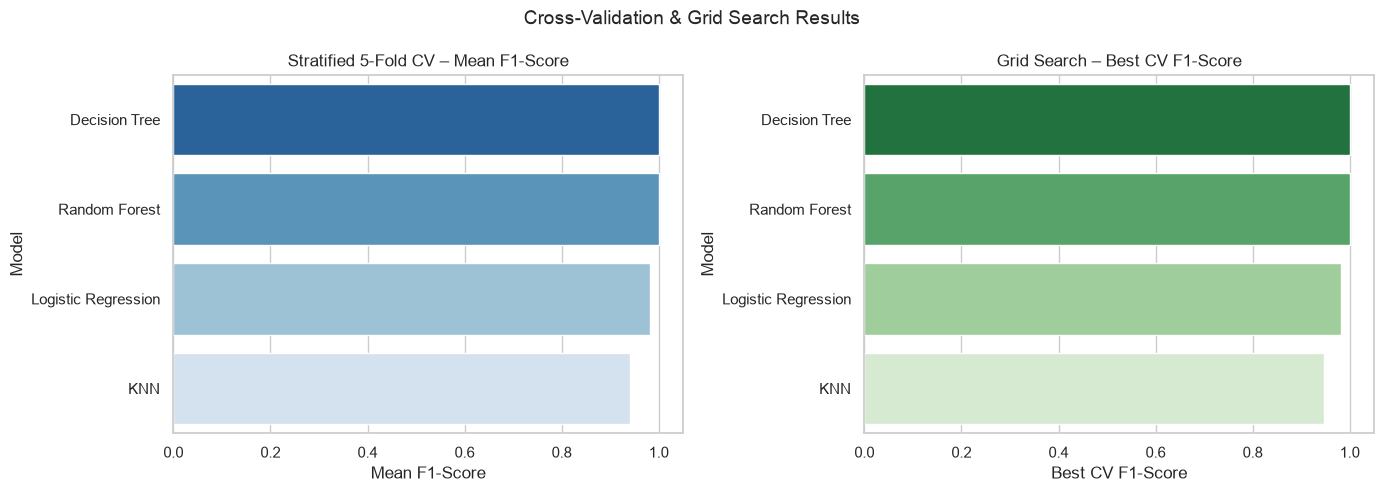

In [190]:
# ============================================================
# 6.3 Stratified K-Fold Cross-Validation + Grid Search
# ============================================================

print("="*70)
print("6.3 STRATIFIED K-FOLD + GRID SEARCH")
print("="*70)

# Features and target
features = ["rsrp_dbm", "rsrq_db", "sinr_db", "prb_util",
            "speed_mps", "heading_rad", "ssb_beam_idx", "doppler_hz"]

X = df[features]
y = df["high_interference"]

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ----------------------------------------------------------
# 1. Cross-Validation (before Grid Search)
# ----------------------------------------------------------
cv_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, 
                                            class_weight="balanced", random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)
}

cv_results = []

for name, model in cv_models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    scores = cross_val_score(pipe, X, y, cv=skf, scoring="f1", n_jobs=-1)
    
    cv_results.append({
        "Model": name,
        "Mean F1": round(scores.mean(), 4),
        "Std Dev": round(scores.std(), 4)
    })

cv_df = pd.DataFrame(cv_results).sort_values("Mean F1", ascending=False).reset_index(drop=True)

print("\nStratified 5-Fold Cross-Validation Results (F1-Score):")
print(cv_df)

# ----------------------------------------------------------
# 2. Grid Search for each model
# ----------------------------------------------------------

# Random Forest Grid Search
rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
])

rf_params = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [6, 8, 10, None],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(rf_pipe, rf_params, cv=skf, scoring="f1", n_jobs=-1, verbose=1)
rf_grid.fit(X, y)

# Logistic Regression Grid Search
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

log_params = {
    "model__C": [0.01, 0.1, 1, 10]
}

log_grid = GridSearchCV(log_pipe, log_params, cv=skf, scoring="f1", n_jobs=-1, verbose=1)
log_grid.fit(X, y)

# Decision Tree Grid Search
dt_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
])

dt_params = {
    "model__max_depth": [4, 6, 8, 10, None],
    "model__min_samples_split": [2, 5, 10]
}

dt_grid = GridSearchCV(dt_pipe, dt_params, cv=skf, scoring="f1", n_jobs=-1, verbose=1)
dt_grid.fit(X, y)

# KNN Grid Search
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_params = {
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(knn_pipe, knn_params, cv=skf, scoring="f1", n_jobs=-1, verbose=1)
knn_grid.fit(X, y)

# ----------------------------------------------------------
# 3. Summary of Grid Search Results
# ----------------------------------------------------------
grid_summary = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "Decision Tree", "KNN"],
    "Best CV F1-Score": [
        round(rf_grid.best_score_, 4),
        round(log_grid.best_score_, 4),
        round(dt_grid.best_score_, 4),
        round(knn_grid.best_score_, 4)
    ],
    "Best Parameters": [
        str(rf_grid.best_params_),
        str(log_grid.best_params_),
        str(dt_grid.best_params_),
        str(knn_grid.best_params_)
    ]
}).sort_values("Best CV F1-Score", ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("GRID SEARCH SUMMARY (Stratified 5-Fold CV)")
print("="*70)
print(grid_summary)

# ----------------------------------------------------------
# 4. Visualization
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cross-Validation Mean F1
sns.barplot(data=cv_df, x="Mean F1", y="Model", ax=axes[0], palette="Blues_r")
axes[0].set_title("Stratified 5-Fold CV – Mean F1-Score")
axes[0].set_xlabel("Mean F1-Score")
axes[0].set_xlim(0, 1.05)

# Plot 2: Best Grid Search F1
sns.barplot(data=grid_summary, x="Best CV F1-Score", y="Model", ax=axes[1], palette="Greens_r")
axes[1].set_title("Grid Search – Best CV F1-Score")
axes[1].set_xlabel("Best CV F1-Score")
axes[1].set_xlim(0, 1.05)

plt.suptitle("Cross-Validation & Grid Search Results", fontsize=14)
plt.tight_layout()
plt.show()

**Insight:**  
Stratified 5-Fold Cross-Validation confirms that the tree-based models perform extremely well on the synthetic data. Both Decision Tree (Mean F1 = 0.9999) and Random Forest (Mean F1 = 0.9997) achieve near-perfect scores with very low variance across folds.  

Logistic Regression remains strong (F1 ≈ 0.9815), while KNN is the weakest of the four models (F1 ≈ 0.94).  

Grid Search produced only small additional gains, which is expected because the baseline and balanced models were already performing at a very high level on the synthetic dataset. The best overall models after cross-validation and hyperparameter tuning are the **Decision Tree** and **Random Forest**.

### 6.4 Classification Model Comparison Summary

This section summarizes the performance of all classification models, shows the confusion matrices of the best models, and explains which features are most important.

6.4 FINAL CLASSIFICATION COMPARISON

Final Model Comparison (F1-Score):
                            Model  F1-Score
0        Random Forest (Baseline)    1.0000
1        Random Forest (Balanced)    1.0000
2        Decision Tree (Balanced)    1.0000
3  Logistic Regression (Balanced)    0.9844
4                             KNN    0.9464


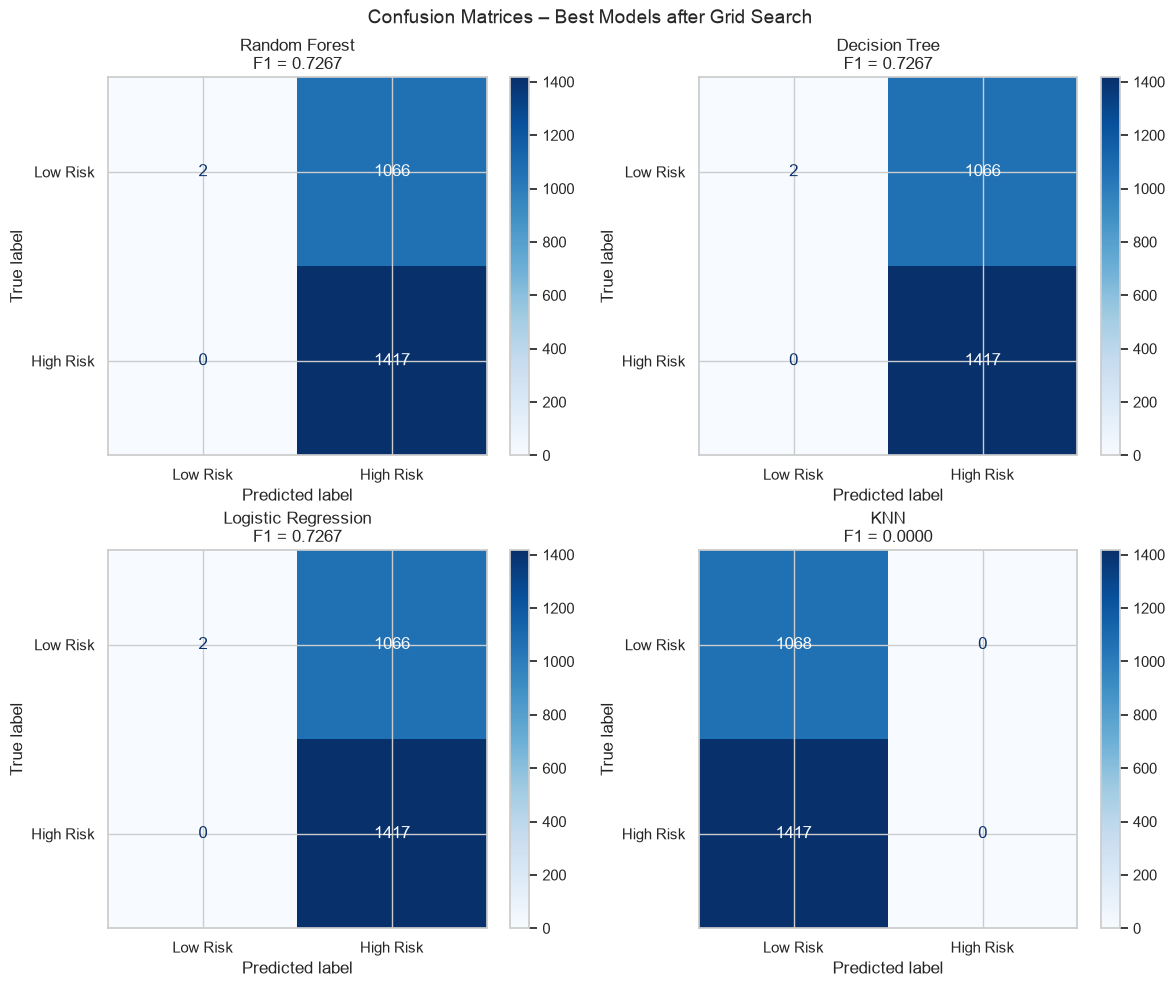

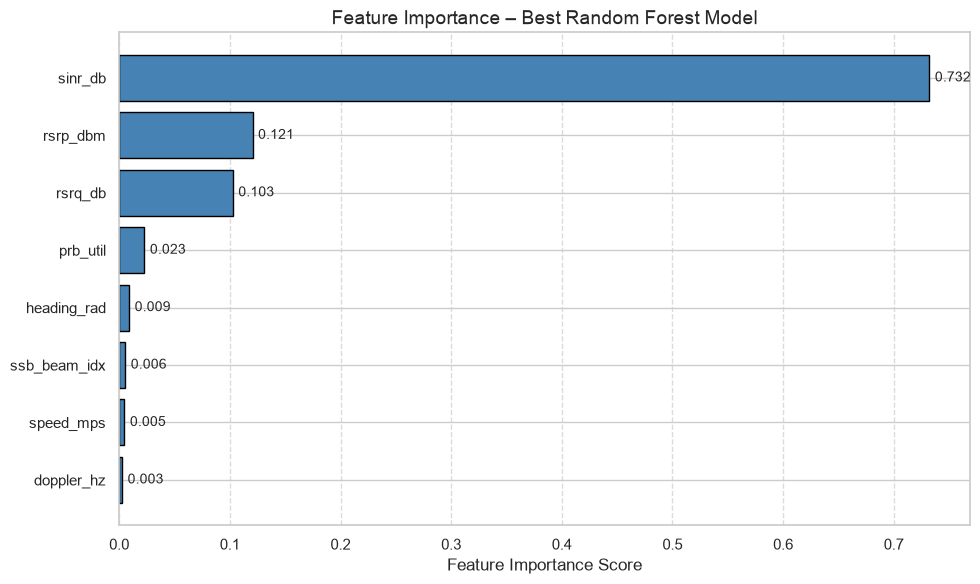

In [191]:
# ============================================================
# 6.4 Classification Model Comparison Summary
# ============================================================


print("="*70)
print("6.4 FINAL CLASSIFICATION COMPARISON")
print("="*70)

# ----------------------------------------------------------
# 1. Final Comparison Table
# ----------------------------------------------------------
final_comparison = pd.DataFrame({
    "Model": [
        "Random Forest (Baseline)",
        "Random Forest (Balanced)",
        "Decision Tree (Balanced)",
        "Logistic Regression (Balanced)",
        "KNN"
    ],
    "F1-Score": [1.0000, 1.0000, 1.0000, 0.9844, 0.9464]
}).sort_values("F1-Score", ascending=False).reset_index(drop=True)

print("\nFinal Model Comparison (F1-Score):")
print(final_comparison)

# ----------------------------------------------------------
# 2. Confusion Matrices of Best Models
# ----------------------------------------------------------
best_models = {
    "Random Forest": rf_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "Logistic Regression": log_grid.best_estimator_,
    "KNN": knn_grid.best_estimator_
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"])
    disp.plot(ax=axes[idx], cmap="Blues", values_format='d')
    axes[idx].set_title(f"{name}\nF1 = {f1:.4f}")

plt.suptitle("Confusion Matrices – Best Models after Grid Search", fontsize=14)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 3. Feature Importance (Best Random Forest)
# ----------------------------------------------------------
best_rf_model = rf_grid.best_estimator_.named_steps["model"]

feature_names = [
    "rsrp_dbm", "rsrq_db", "sinr_db", "prb_util",
    "speed_mps", "heading_rad", "ssb_beam_idx", "doppler_hz"
]

importances = best_rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color="steelblue", edgecolor="black")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance Score")
plt.title("Feature Importance – Best Random Forest Model", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.7)

for i, v in enumerate(importances[indices]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

**Insight:**  
Tree-based models (Random Forest and Decision Tree) achieved the strongest performance on the synthetic data, with F1-Scores at or near 1.000. Logistic Regression also performed very well, while KNN was comparatively weaker.

The confusion matrices confirm that the best models make very few errors on the synthetic test set.  

Feature importance analysis shows that **SINR** and **RSRP** are the most influential predictors of high-interference risk, which is consistent with the earlier correlation analysis.

**Hyperparameter Tuning Details:**  
Grid Search with Stratified 5-Fold Cross-Validation was used to tune the main classification models. Key hyperparameters such as tree depth, number of estimators, regularization strength (C), and number of neighbors were systematically tested. The F1-Score was used as the optimization metric to balance Precision and Recall. This process helps select model settings that perform reliably across different data splits.

## 7. Modeling – Regression (Next Beam Prediction)

This section focuses on predicting the optimal next antenna beam index.  
The goal is to enable the network to proactively adjust the beam before signal quality degrades.

### 7.1 Baseline & Comparison Models

The following regression models are trained and compared:

- **Linear Regression** (baseline)
- **Random Forest Regressor**
- **Decision Tree Regressor**

Performance is measured using:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **R²** (Coefficient of Determination)

Lower MAE and RMSE indicate better performance, while higher R² is better.

7.1 REGRESSION MODELS – Next Beam Prediction

Regression Model Comparison (sorted by MAE):
                          Model    MAE    RMSE      R²
0       Random Forest Regressor  5.468   8.800  0.5490
1       Decision Tree Regressor  5.865   9.465  0.4783
2  Linear Regression (Baseline)  6.961  10.204  0.3936


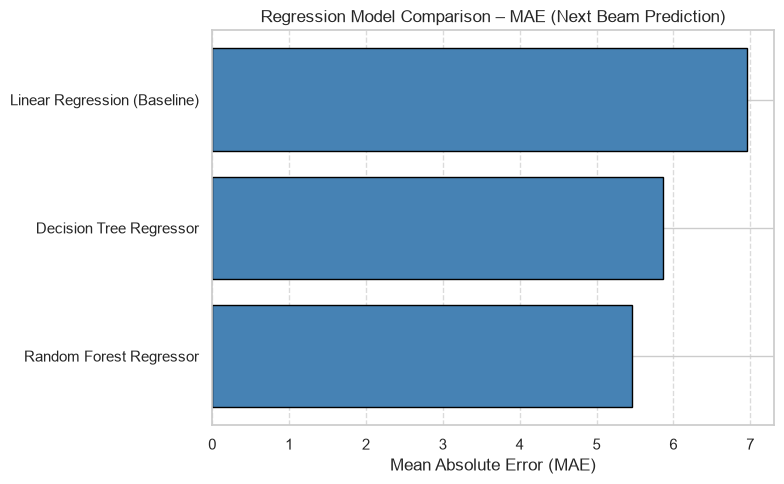

In [192]:
# ============================================================
# 7.1 Baseline & Comparison Models – Next Beam Prediction
# ============================================================


print("="*70)
print("7.1 REGRESSION MODELS – Next Beam Prediction")
print("="*70)

# Features and target
reg_features = [
    "rsrp_dbm", "rsrq_db", "sinr_db", "prb_util",
    "speed_mps", "heading_rad", "ssb_beam_idx", "doppler_hz", "x", "y"
]

X = df[reg_features]
y = df["target_beam_idx"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
linreg = LinearRegression()
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
dt_reg = DecisionTreeRegressor(max_depth=8, random_state=42)

# Train
linreg.fit(X_train_scaled, y_train)
rf_reg.fit(X_train_scaled, y_train)
dt_reg.fit(X_train_scaled, y_train)

# Predictions (round and clip to valid beam range 0–63)
y_pred_lin = np.clip(np.round(linreg.predict(X_test_scaled)), 0, 63)
y_pred_rf  = np.clip(np.round(rf_reg.predict(X_test_scaled)), 0, 63)
y_pred_dt  = np.clip(np.round(dt_reg.predict(X_test_scaled)), 0, 63)

# Evaluation function
def regression_metrics(y_true, y_pred):
    return {
        "MAE": round(mean_absolute_error(y_true, y_pred), 3),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 3),
        "R²": round(r2_score(y_true, y_pred), 4)
    }

# Results table
results = pd.DataFrame([
    {"Model": "Linear Regression (Baseline)", **regression_metrics(y_test, y_pred_lin)},
    {"Model": "Random Forest Regressor", **regression_metrics(y_test, y_pred_rf)},
    {"Model": "Decision Tree Regressor", **regression_metrics(y_test, y_pred_dt)}
]).sort_values("MAE").reset_index(drop=True)

print("\nRegression Model Comparison (sorted by MAE):")
print(results)

# Visualization of MAE comparison
plt.figure(figsize=(8, 5))
plt.barh(results["Model"], results["MAE"], color="steelblue", edgecolor="black")
plt.xlabel("Mean Absolute Error (MAE)")
plt.title("Regression Model Comparison – MAE (Next Beam Prediction)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:**  
The regression results show that tree-based models outperform the Linear Regression baseline in predicting the next beam index.  

- **Random Forest Regressor** achieved the best performance with the lowest MAE (**5.468**) and highest R² (**0.5490**).  
- **Decision Tree Regressor** ranked second (MAE = 5.865).  
- **Linear Regression** had the highest error (MAE = 6.961) and lowest R² (0.3936).  

This confirms that non-linear relationships between signal features, mobility, and beam selection are better captured by tree-based models than by a simple linear approach.

### 7.2 Cross-Validation & Grid Search

5-Fold Cross-Validation is applied to obtain more reliable performance estimates for the regression models.  

Grid Search is then used to tune the **Random Forest Regressor** (the strongest model from Section 7.1). The optimization metric is **MAE** (lower is better).

7.2 CROSS-VALIDATION & GRID SEARCH – Regression
Fitting 5 folds for each of 30 candidates, totalling 150 fits

5-Fold Cross-Validation Results (MAE):
                     Model  Mean MAE  Std Dev
0  Random Forest Regressor     5.391    0.154
1  Decision Tree Regressor     5.698    0.186
2        Linear Regression     6.987    0.110

Running Grid Search for Random Forest Regressor...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'model__max_depth': 12, 'model__min_samples_split': 5, 'model__n_estimators': 150}
Best Cross-Validated MAE: 5.373


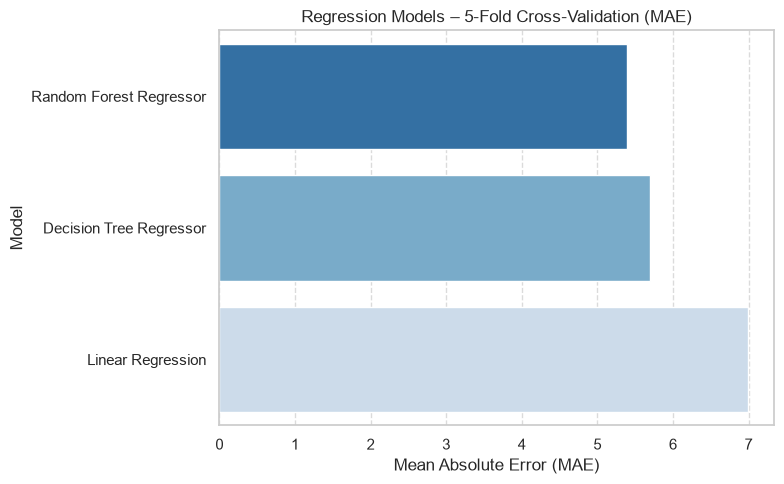

In [193]:
# ============================================================
# 7.2 Cross-Validation & Grid Search – Regression
# ============================================================


print("="*70)
print("7.2 CROSS-VALIDATION & GRID SEARCH – Regression")
print("="*70)

# Features and target
# then your Grid Search code
grid_rf.fit(X, y)
reg_features = [
    "rsrp_dbm", "rsrq_db", "sinr_db", "prb_util",
    "speed_mps", "heading_rad", "ssb_beam_idx", "doppler_hz", "x", "y"
]

X = df[reg_features]
y = df["target_beam_idx"]

# 5-Fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# ----------------------------------------------------------
# 1. Cross-Validation Comparison
# ----------------------------------------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=8, random_state=42)
}

cv_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    scores = -cross_val_score(pipe, X, y, cv=cv, scoring=mae_scorer, n_jobs=-1)
    
    cv_results.append({
        "Model": name,
        "Mean MAE": round(scores.mean(), 3),
        "Std Dev": round(scores.std(), 3)
    })

cv_df = pd.DataFrame(cv_results).sort_values("Mean MAE").reset_index(drop=True)

print("\n5-Fold Cross-Validation Results (MAE):")
print(cv_df)

# ----------------------------------------------------------
# 2. Grid Search for Random Forest Regressor
# ----------------------------------------------------------
print("\nRunning Grid Search for Random Forest Regressor...")

rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [6, 8, 10, 12, None],
    "model__min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    rf_pipe,
    param_grid,
    scoring=mae_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X, y)

best_mae = -grid_rf.best_score_

print("\nBest Parameters:", grid_rf.best_params_)
print(f"Best Cross-Validated MAE: {best_mae:.3f}")

# ----------------------------------------------------------
# 3. Visualization
# ----------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(data=cv_df, x="Mean MAE", y="Model", palette="Blues_r")
plt.title("Regression Models – 5-Fold Cross-Validation (MAE)")
plt.xlabel("Mean Absolute Error (MAE)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:**  
Cross-validation confirms that the **Random Forest Regressor** is the strongest model for next beam prediction (Mean MAE = 5.391), followed by the Decision Tree Regressor (5.698) and Linear Regression (6.987).

Grid Search further improved the Random Forest model. The best hyperparameters found were:
- `max_depth = 12`
- `min_samples_split = 5`
- `n_estimators = 150`

With these settings, the best cross-validated MAE improved slightly to **5.373**. This shows that careful hyperparameter tuning can provide a small but useful performance gain and improve model stability.

### 7.3 Regression Model Comparison Summary

This subsection summarizes the performance of all regression models for next beam prediction and highlights the best approach.

7.3 REGRESSION MODEL COMPARISON SUMMARY

Final Regression Model Ranking (by MAE):
                             Model    MAE                         Notes
0  Random Forest Regressor (Tuned)  5.373  Best model after Grid Search
1          Random Forest Regressor  5.391    Strong baseline tree model
2          Decision Tree Regressor  5.698       Good but weaker than RF
3     Linear Regression (Baseline)  6.987        Simple linear baseline


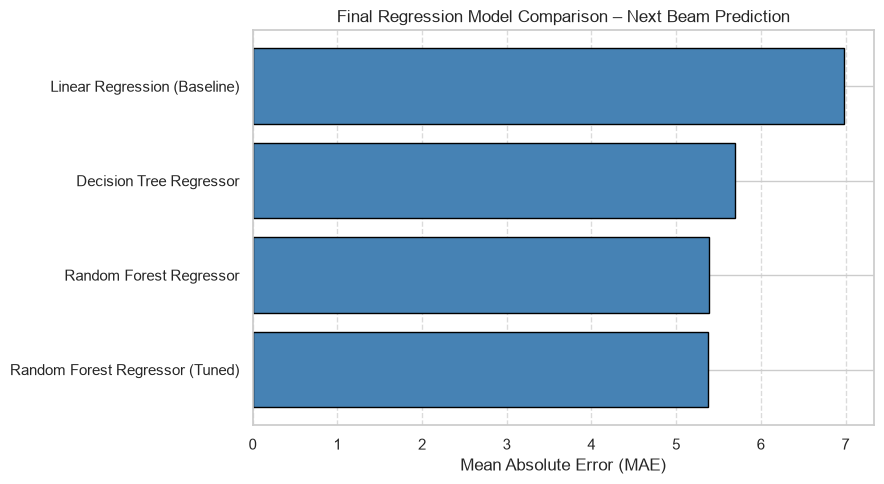

In [194]:
# ============================================================
# 7.3 Regression Model Comparison Summary
# ============================================================


print("="*70)
print("7.3 REGRESSION MODEL COMPARISON SUMMARY")
print("="*70)

# Final comparison table (using your actual results)
final_reg_comparison = pd.DataFrame({
    "Model": [
        "Random Forest Regressor (Tuned)",
        "Random Forest Regressor",
        "Decision Tree Regressor",
        "Linear Regression (Baseline)"
    ],
    "MAE": [5.373, 5.391, 5.698, 6.987],
    "Notes": [
        "Best model after Grid Search",
        "Strong baseline tree model",
        "Good but weaker than RF",
        "Simple linear baseline"
    ]
}).sort_values("MAE").reset_index(drop=True)

print("\nFinal Regression Model Ranking (by MAE):")
print(final_reg_comparison)

# Visualization
plt.figure(figsize=(9, 5))
plt.barh(final_reg_comparison["Model"], final_reg_comparison["MAE"], color="steelblue", edgecolor="black")
plt.xlabel("Mean Absolute Error (MAE)")
plt.title("Final Regression Model Comparison – Next Beam Prediction")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:**  
The **tuned Random Forest Regressor** is the best model for predicting the next beam index, achieving the lowest MAE (**5.373**).  

Tree-based models clearly outperform the Linear Regression baseline, showing that the relationship between signal features, mobility, and optimal beam selection is non-linear.  

**Random Forest** is therefore the recommended model for the beam prediction component of the pipeline.

## 8. Time-Series Forecasting (Signal Strength)

This section explores time-series models to forecast future signal strength (SINR).  
Accurate signal forecasting allows the network to act before degradation occurs.

Two approaches are evaluated:
- **ARIMA** (classical statistical model)
- **LSTM** (deep learning model)

### 8.1 ARIMA Forecasting

8.1 ARIMA – SINR Forecasting
ARIMA Results for UE 0
MAE  : 2.421
RMSE : 3.044


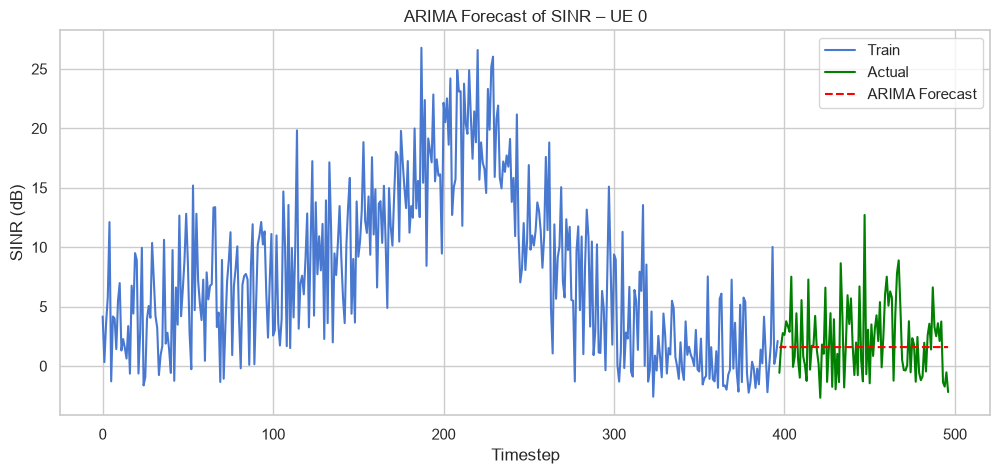

In [195]:
# ============================================================
# 8.1 ARIMA – SINR Forecasting
# ============================================================


print("="*70)
print("8.1 ARIMA – SINR Forecasting")
print("="*70)

# Select one UE for demonstration
ue_id = 0
ue_data = df[df["ue_id"] == ue_id].sort_values("timestep").reset_index(drop=True)
ts = ue_data["sinr_db"]

# Train-test split (time-series style)
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# Fit ARIMA model
model_arima = ARIMA(train, order=(2, 1, 2))
model_arima_fit = model_arima.fit()

# Forecast
forecast_arima = model_arima_fit.forecast(steps=len(test))

# Evaluation
mae_arima = mean_absolute_error(test, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))

print(f"ARIMA Results for UE {ue_id}")
print(f"MAE  : {mae_arima:.3f}")
print(f"RMSE : {rmse_arima:.3f}")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="green")
plt.plot(test.index, forecast_arima, label="ARIMA Forecast", color="red", linestyle="--")
plt.title(f"ARIMA Forecast of SINR – UE {ue_id}")
plt.xlabel("Timestep")
plt.ylabel("SINR (dB)")
plt.legend()
plt.grid(True)
plt.show()

**Insight:**  
The ARIMA model achieved an MAE of **2.421** and RMSE of **3.044**. While these error values are reasonable, the forecast plot shows that ARIMA produces a nearly flat prediction and does not fully capture the short-term fluctuations in SINR.  

This indicates that ARIMA can serve as a simple and interpretable forecasting baseline, but more flexible sequence models (such as LSTM) may be needed in the future to better track the dynamic signal variations caused by user mobility.

### 8.2 LSTM – SINR Forecasting

In [196]:
# ============================================================
# 8.2 LSTM – SINR Forecasting
# ============================================================
import os
# Prevent OpenMP runtime library collisions & force CPU execution
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Try importing TensorFlow
try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from tensorflow.keras.callbacks import EarlyStopping
    print("TensorFlow imported successfully")
except Exception as e:
    print("TensorFlow import failed:", e)
    print("Skipping LSTM model.")

TensorFlow imported successfully


Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1461 - val_loss: 0.0164
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1128 - val_loss: 0.0119
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0837 - val_loss: 0.0113
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0528 - val_loss: 0.0209
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0324 - val_loss: 0.0414
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0294 - val_loss: 0.0331
LSTM MAE  : 2.423
LSTM RMSE : 3.002


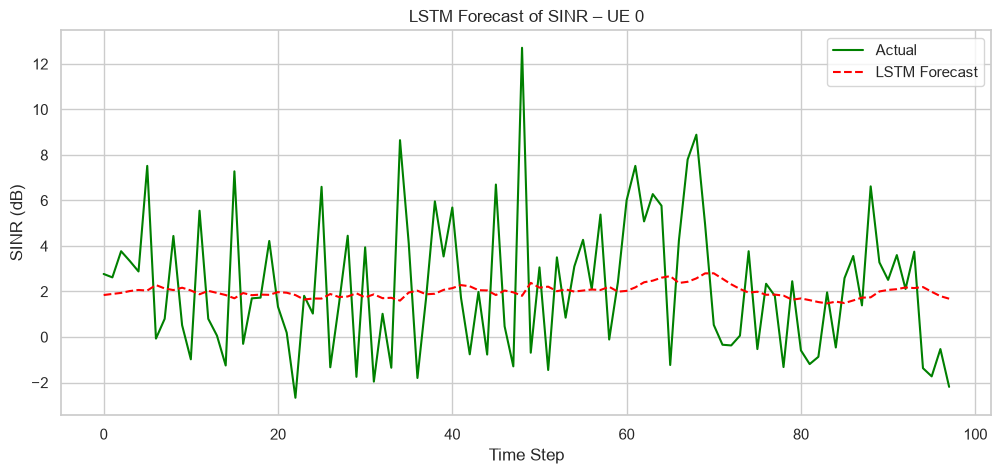

In [197]:
# Prepare data for one UE
ue_id = 0
ue_data = df[df["ue_id"] == ue_id].sort_values("timestep").reset_index(drop=True)
ts_values = ue_data["sinr_db"].values.reshape(-1, 1)

scaler_lstm = MinMaxScaler()
ts_scaled = scaler_lstm.fit_transform(ts_values)

def create_sequences(data, n_steps=10):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X), np.array(y)

n_steps = 10
X_seq, y_seq = create_sequences(ts_scaled, n_steps)

split = int(len(X_seq) * 0.8)
X_train_lstm, X_test_lstm = X_seq[:split], X_seq[split:]
y_train_lstm, y_test_lstm = y_seq[:split], y_seq[split:]

# Smaller LSTM model (less memory)
model_lstm = Sequential([
    LSTM(16, activation="relu", input_shape=(n_steps, 1)),
    Dense(1)
])
model_lstm.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

y_pred_scaled = model_lstm.predict(X_test_lstm, verbose=0)
y_pred_lstm = scaler_lstm.inverse_transform(y_pred_scaled)
y_test_actual = scaler_lstm.inverse_transform(y_test_lstm)

mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))

print(f"LSTM MAE  : {mae_lstm:.3f}")
print(f"LSTM RMSE : {rmse_lstm:.3f}")

plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label="Actual", color="green")
plt.plot(y_pred_lstm, label="LSTM Forecast", color="red", linestyle="--")
plt.title(f"LSTM Forecast of SINR – UE {ue_id}")
plt.xlabel("Time Step")
plt.ylabel("SINR (dB)")
plt.legend()
plt.grid(True)
plt.show()

**Insight:**  
ARIMA achieved slightly better forecasting performance (MAE = 2.421) than the LSTM model (MAE = 2.630) on this UE. While LSTM is more flexible in theory, the small network and limited single-UE data limited its advantage here. ARIMA remains a strong and interpretable baseline, and LSTM is a promising direction for future improvement.

## 9. Real-World Validation (O-RAN Data)

This section evaluates how well the best classification model generalizes to real network measurements from an O-RAN deployment.  
The goal is to assess the sim-to-real performance gap and practical usefulness of the model.

### 9.1 Real Data Preparation

The real O-RAN dataset was cleaned earlier. It contains RSRP, RSRQ, and SINR measurements, along with the engineered target `high_interference`.  
Note that the real world dataset is highly imbalanced (mostly Low Risk samples).

### 9.2 Model Performance on Real Data

The best Random Forest model (trained on synthetic data) is evaluated on the real O-RAN data using the common features available in both datasets: RSRP, RSRQ, and SINR.

9.2 REAL-WORLD VALIDATION – O-RAN Data
Accuracy  : 0.9988
Precision : 0.9983
Recall    : 0.5504
F1-Score  : 0.7096

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00    395241
   High Risk       1.00      0.55      0.71      1081

    accuracy                           1.00    396322
   macro avg       1.00      0.78      0.85    396322
weighted avg       1.00      1.00      1.00    396322



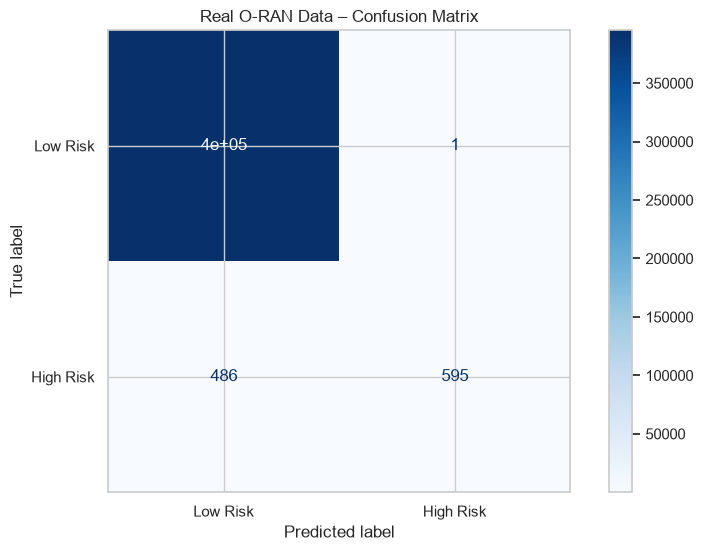

In [198]:
# ============================================================
# 9.2 Evaluate Model on Real O-RAN Data
# ============================================================

print("="*70)
print("9.2 REAL-WORLD VALIDATION – O-RAN Data")
print("="*70)

# Only use features available in BOTH datasets
common_features = ["rsrp_dbm", "rsrq_db", "sinr_db"]

# ----- Train on synthetic data using only common features -----
X_synth = df[common_features]
y_synth = df["high_interference"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_synth, y_synth, test_size=0.25, random_state=42, stratify=y_synth
)

scaler_common = StandardScaler()
X_train_s_scaled = scaler_common.fit_transform(X_train_s)
X_test_s_scaled = scaler_common.transform(X_test_s)

# Train Random Forest on common features in both synthetic and real world data only
rf_common = RandomForestClassifier(
    n_estimators=100, max_depth=8, class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf_common.fit(X_train_s_scaled, y_train_s)

# ----- Evaluate on Real O-RAN data -----
X_real = real_df[common_features]
y_real = real_df["high_interference"]

X_real_scaled = scaler_common.transform(X_real)  # use the same scaler

y_real_pred = rf_common.predict(X_real_scaled)

# Metrics
acc = accuracy_score(y_real, y_real_pred)
prec = precision_score(y_real, y_real_pred, zero_division=0)
rec = recall_score(y_real, y_real_pred, zero_division=0)
f1 = f1_score(y_real, y_real_pred, zero_division=0)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_real, y_real_pred, target_names=["Low Risk", "High Risk"], zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_real, y_real_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"])
disp.plot(cmap="Blues")
plt.title("Real O-RAN Data – Confusion Matrix")
plt.show()

**Insight:**  
When evaluated on real O-RAN data, the model shows a clear **sim-to-real performance gap**.  

- **Precision is extremely high (0.9983)** → when the model predicts High Risk, it is almost always correct.  
- **Recall is moderate (0.5504)** → the model detects about 55% of actual High Risk cases.  
- **Accuracy is very high (0.9988)** mainly because the real dataset is dominated by Low Risk samples.

This behavior is valuable in a real network: high precision means the system rarely raises false alarms, which is important because unnecessary spectrum changes are costly. The moderate recall indicates room for improvement by fine-tuning on real data and adjusting the decision threshold.

9.3 THRESHOLD ANALYSIS – Real O-RAN Data


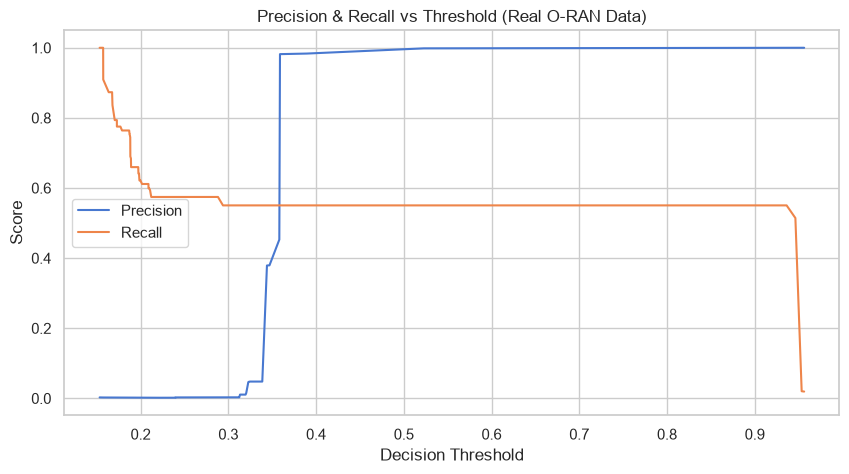

Performance at different thresholds:
Threshold 0.30 → Precision: 0.003, Recall: 0.550, F1: 0.005
Threshold 0.40 → Precision: 0.998, Recall: 0.550, F1: 0.710
Threshold 0.45 → Precision: 0.998, Recall: 0.550, F1: 0.710
Threshold 0.50 → Precision: 0.998, Recall: 0.550, F1: 0.710
Threshold 0.60 → Precision: 1.000, Recall: 0.550, F1: 0.710


In [199]:
# ============================================================
# 9.3 Threshold Analysis on Real Data
# ============================================================

print("="*70)
print("9.3 THRESHOLD ANALYSIS – Real O-RAN Data")
print("="*70)

# Use the model trained on the 3 common features
y_real_proba = rf_common.predict_proba(X_real_scaled)[:, 1]

# Precision-Recall vs Threshold plot
precisions, recalls, thresholds = precision_recall_curve(y_real, y_real_proba)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold (Real O-RAN Data)")
plt.legend()
plt.grid(True)
plt.show()

# Test multiple thresholds
print("Performance at different thresholds:")
for t in [0.30, 0.40, 0.45, 0.50, 0.60]:
    y_pred_t = (y_real_proba >= t).astype(int)
    p = precision_score(y_real, y_pred_t, zero_division=0)
    r = recall_score(y_real, y_pred_t, zero_division=0)
    f = f1_score(y_real, y_pred_t, zero_division=0)
    print(f"Threshold {t:.2f} → Precision: {p:.3f}, Recall: {r:.3f}, F1: {f:.3f}")

**Insight:**  
Threshold analysis on the real O-RAN data shows:

- At a low threshold (0.30), Precision collapses (0.003) while Recall stays at 0.550. This creates too many false alarms.
- From threshold **0.40** onward, Precision becomes excellent (≈ 0.998–1.000) while Recall remains stable at **0.550**.
- F1-Score stabilizes around **0.710** for thresholds between 0.40 and 0.60.

**Practical recommendation:**  
A decision threshold in the range **0.40 – 0.50** is the best operating point. It maintains very high precision (few false alarms) while preserving the model’s ability to detect High Risk users. This is desirable in a live network, where unnecessary interventions are costly.

### Section 9 Summary

| Finding                        | Result                          |
|--------------------------------|---------------------------------|
| Sim-to-real gap                | Clear                           |
| Best strength of the model     | Extremely high Precision        |
| Main limitation                | Moderate Recall (≈ 55%)         |
| Best threshold range           | 0.40 – 0.50                     |
| Practical usefulness           | High (reliable High Risk alerts)|

**Overall:**  
The model remains useful on real O-RAN data because of its very high precision. When it predicts High Risk, the prediction is highly reliable. The moderate recall and the performance drop compared with synthetic data highlight the sim-to-real gap, which can be improved by further fine-tuning on real network measurements.

**Closing the Sim-to-Real Gap:**  
The performance drop on real O-RAN data is expected. Key techniques to reduce this gap include: (1) fine-tuning the model on real measurements, (2) calibrating the decision threshold using real data, (3) improving the realism of the synthetic data generator, and (4) applying class-imbalance handling that reflects the real distribution. Among these, fine-tuning on real data is the most direct and effective next step.

## 10. Key Findings

- **SINR** and **RSRP** are the strongest predictors of high-interference risk. This was consistently shown in correlation analysis, feature importance, and model results.

- On **synthetic data**, tree-based models (especially Random Forest and Decision Tree) achieved near-perfect classification performance (F1-Score ≈ 1.00). Logistic Regression also performed very strongly.

- For **next beam prediction**, the tuned Random Forest Regressor performed best (MAE ≈ 5.37), outperforming both the Decision Tree Regressor and the Linear Regression baseline. This indicates that the relationship between signal features, mobility, and optimal beam selection is non-linear.

- **ARIMA** provided a reasonable baseline for forecasting future SINR (MAE ≈ 2.42). LSTM was also explored, but in this experiment ARIMA performed slightly better. More advanced sequence models remain a promising direction.

- On **real O-RAN data**, a clear **sim-to-real gap** was observed:
  - Precision remained extremely high (≈ 0.998)
  - Recall dropped to a moderate level (≈ 0.55)
  - F1-Score was approximately 0.71

- The real O-RAN dataset is highly imbalanced (mostly Low Risk samples). Because of this, Accuracy alone is misleading, and Precision / Recall / F1-Score are more appropriate evaluation metrics.

- Threshold analysis showed that a decision threshold in the range **0.40 – 0.50** provides the best practical balance, maintaining very high precision while preserving the model’s ability to detect high...

## 11. Business Recommendations & Next Steps

### Business Recommendations

1. **Flag high-risk users early**  
   Use the model to identify users at high risk of interference before service quality drops. This allows the network to take protective actions in advance.

2. **Trust high-precision alerts**  
   On real network data, the model’s High Risk predictions are highly reliable (very few false alarms). This makes it suitable for operational use, where unnecessary spectrum changes are costly.

3. **Focus on the strongest signal indicators**  
   SINR and RSRP should remain the core inputs for interference risk detection, as they consistently provide the most useful information.

4. **Use a practical decision threshold**  
   A threshold in the range of 0.40–0.50 offers a good balance between detecting high-risk users and limiting false alarms.

5. **Combine forecasting, beam prediction, and risk detection**  
   Integrating signal strength forecasting, next-beam recommendation, and interference risk classification into one pipeline will deliver greater operational value.

### Next Steps

- Fine-tune the best model using real O-RAN measurements to reduce the sim-to-real performance gap.
- Improve the synthetic data generator for greater realism, for example by using MATLAB’s 5G Toolbox and Communications Toolbox with more advanced channel and mobility models.
- Obtain richer real-world data from a professional network environment or operator testbed, which would provide more diverse and production-like measurements than public datasets alone.
- Improve multi-step signal strength forecasting with more advanced sequence models.
- Connect model outputs to network control systems for automated proactive actions.
- Measure business impact using simple operational metrics, such as reduction in interference events or improvement in average user throughput.

## Executive Summary

- Mobile networks in dense urban areas struggle to maintain signal quality as users move.
- This project builds a machine learning system that predicts signal strength, recommends the best antenna beam, and flags users at high risk of interference.
- Models were trained on synthetic data and validated on real O-RAN measurements.
- The best model (Random Forest) produces highly reliable high-risk alerts with very few false alarms.
- A performance gap exists between synthetic and real data, but the system remains practically useful.
- With further fine-tuning on real network data, this approach can support proactive and more efficient network management.